<a href="https://colab.research.google.com/github/Youssef-Hamdy-Mahmoud/Auto-Cars-Sales-PROJECT1/blob/main/Classification_DSS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 1 — Import Libraries

In [26]:
Cell 1 — Import Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
import io

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

Cell 2 — Upload and Load Dataset

In [30]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset shape:", df.shape)
display(df.head())

Saving diabetes_prediction_dataset.csv to diabetes_prediction_dataset (1).csv
Dataset shape: (10002, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


Cell 3 — Reduce Dataset to 10,000

In [31]:
df = (
    df.groupby("diabetes", group_keys=False)
    .apply(lambda x: x.sample(frac=10000/len(df), random_state=42))
)

df = df.sample(n=10000, random_state=42)

print("New shape:", df.shape)

New shape: (10000, 9)


Cell 4 — Data Exploration

In [32]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nTarget distribution:")
print(df["diabetes"].value_counts())

print("\nSummary:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 8103 to 9847
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               10000 non-null  object 
 1   age                  10000 non-null  float64
 2   hypertension         10000 non-null  int64  
 3   heart_disease        10000 non-null  int64  
 4   smoking_history      10000 non-null  object 
 5   bmi                  10000 non-null  float64
 6   HbA1c_level          10000 non-null  float64
 7   blood_glucose_level  10000 non-null  int64  
 8   diabetes             10000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 781.2+ KB
None

Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicates:
44

Targ

Cell 5 — Visualization

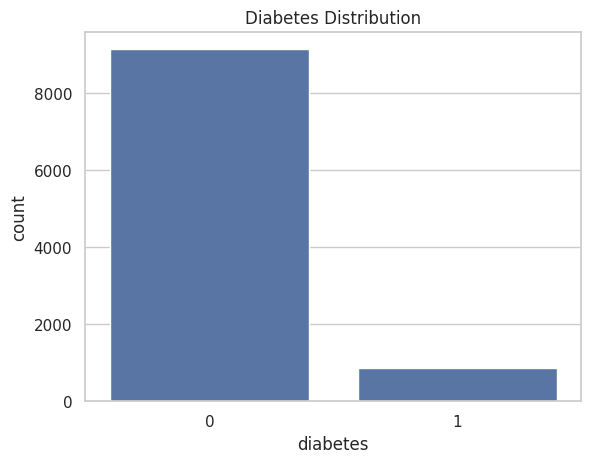

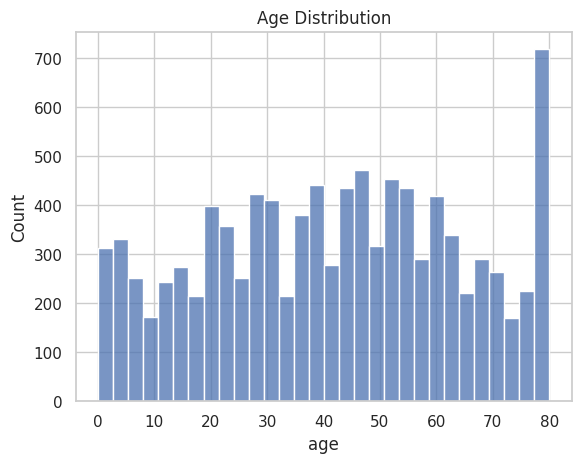

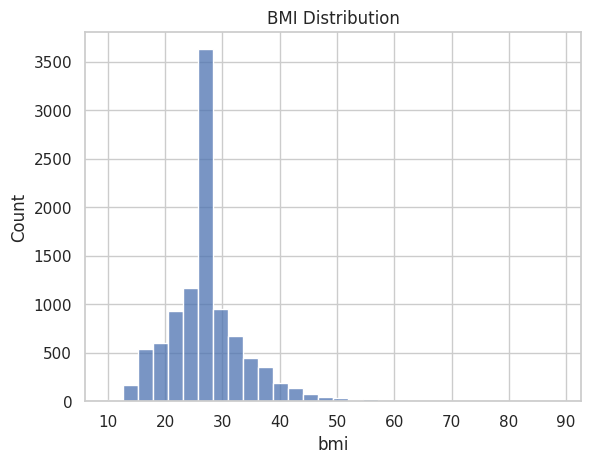

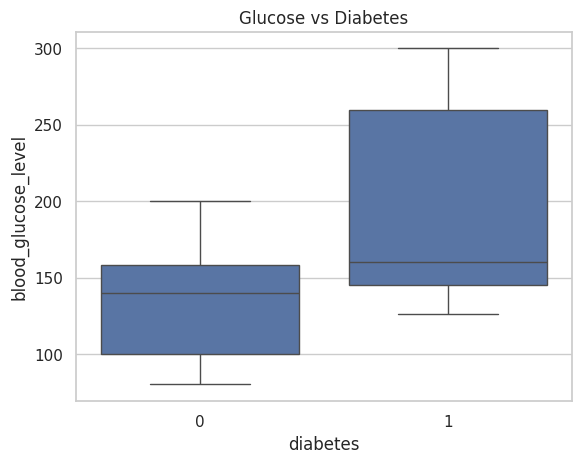

In [33]:
# Target distribution
sns.countplot(x="diabetes", data=df)
plt.title("Diabetes Distribution")
plt.show()

# Age
sns.histplot(df["age"], bins=30)
plt.title("Age Distribution")
plt.show()

# BMI
sns.histplot(df["bmi"], bins=30)
plt.title("BMI Distribution")
plt.show()

# Glucose vs diabetes
sns.boxplot(x="diabetes", y="blood_glucose_level", data=df)
plt.title("Glucose vs Diabetes")
plt.show()

Cell 6 — Preprocessing

In [34]:
df = df.drop_duplicates()

X = df.drop("diabetes", axis=1)
y = df["diabetes"]

categorical_features = ["gender", "smoking_history"]
numeric_features = [
    "age", "hypertension", "heart_disease",
    "bmi", "HbA1c_level", "blood_glucose_level"
]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), numeric_features)
])

Cell 7 — Train/Test Split (70% / 30%)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,   # 30% test → 70% train
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (6969, 8)
Test: (2987, 8)


Cell 8 — Model 1 (Logistic Regression)

In [36]:
model_lr = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy: 0.8948778038165384

Confusion Matrix:
[[2443  286]
 [  28  230]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      2729
           1       0.45      0.89      0.59       258

    accuracy                           0.89      2987
   macro avg       0.72      0.89      0.77      2987
weighted avg       0.94      0.89      0.91      2987



Cell 9 — Model 2 (Naive Bayes)

In [39]:
preprocessor_nb = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ("num", StandardScaler(), numeric_features)
])

model_nb = Pipeline([
    ("preprocessing", preprocessor_nb),
    ("classifier", GaussianNB())
])

model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)

print("Naive Bayes Results")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Results
Accuracy: 0.9009039169735521

Confusion Matrix:
[[2502  227]
 [  69  189]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      2729
           1       0.45      0.73      0.56       258

    accuracy                           0.90      2987
   macro avg       0.71      0.82      0.75      2987
weighted avg       0.93      0.90      0.91      2987



Cell 10 — Model Comparison

,Model,Accuracy
0,Logistic Regression,0.894878
1,Naive Bayes,0.900904


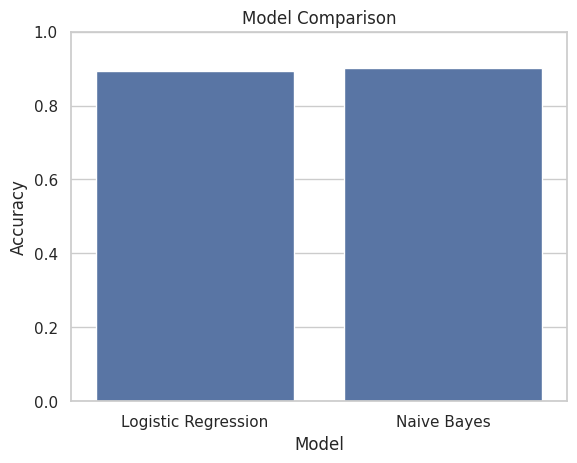

In [40]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_nb = accuracy_score(y_test, y_pred_nb)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [acc_lr, acc_nb]
})

display(results)

sns.barplot(x="Model", y="Accuracy", data=results)
plt.ylim(0, 1)
plt.title("Model Comparison")
plt.show()

Cell 11 — Conclusion

In [41]:
if acc_lr > acc_nb:
    print("Logistic Regression performed better.")
elif acc_nb > acc_lr:
    print("Naive Bayes performed better.")
else:
    print("Both models performed equally.")

print("\nFinal Results:")
print("Logistic Regression Accuracy:", acc_lr)
print("Naive Bayes Accuracy:", acc_nb)

Naive Bayes performed better.

Final Results:
Logistic Regression Accuracy: 0.8948778038165384
Naive Bayes Accuracy: 0.9009039169735521
